<a href="https://colab.research.google.com/github/alejagp27/Primer-despliegue/blob/main/Copia_de_1_Clustering_autos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering -  Proyecto Tasación inteligente de vehiculos usados

1. Preparación de datos: variables numéricas se deben normalizar y variables categóricas se crean dummies
2. Aprendizaje del Modelo: Kmeans, método del codo
3. Evaluación del Modelo: Inertia, silueta
4. Perfilamiento: Descripción de centroides



In [1]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica



# 1. Preparación de Datos

* Previa limpieza de atípicos, nulos y altas correlaciones









In [3]:
# Se cargan los datos
df = pd.read_csv("DF_carros_usados.csv") #Cargar datos en csv
df.head() #muestras los 5 primeros registros

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,brand,price
0,i3,2014,Automatic,34539,Hybrid,0,470.8,0.6,BMW,14495
1,i3,2014,Automatic,37161,Hybrid,0,470.8,0.6,BMW,14182
2,i3,2014,Automatic,42479,Hybrid,0,470.8,0.6,BMW,15450
3,i3,2015,Automatic,9886,Hybrid,0,470.8,0.6,BMW,17481
4,i3,2015,Automatic,33931,Hybrid,0,470.8,0.6,BMW,15498


In [4]:
df = df.drop('model', axis=1)

In [5]:
df.head() #muestras los 5 primeros registros

,year,transmission,mileage,fuelType,tax,mpg,engineSize,brand,price
0,2014,Automatic,34539,Hybrid,0,470.8,0.6,BMW,14495
1,2014,Automatic,37161,Hybrid,0,470.8,0.6,BMW,14182
2,2014,Automatic,42479,Hybrid,0,470.8,0.6,BMW,15450
3,2015,Automatic,9886,Hybrid,0,470.8,0.6,BMW,17481
4,2015,Automatic,33931,Hybrid,0,470.8,0.6,BMW,15498


In [6]:
#Se revisan los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26306 entries, 0 to 26305
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          26306 non-null  int64  
 1   transmission  26306 non-null  object 
 2   mileage       26306 non-null  int64  
 3   fuelType      26306 non-null  object 
 4   tax           26306 non-null  int64  
 5   mpg           26306 non-null  float64
 6   engineSize    26306 non-null  float64
 7   brand         26306 non-null  object 
 8   price         26306 non-null  int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 1.8+ MB


* Transformaciones: normalizar y crear dummies

In [7]:
#Copia de los datos
data=df.copy()


In [8]:
#Correegir tipos de datos
df['transmission']=df['transmission'].astype('category')
df['fuelType']=df['fuelType'].astype('category')
df['brand']=df['brand'].astype('category')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26306 entries, 0 to 26305
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   year          26306 non-null  int64   
 1   transmission  26306 non-null  category
 2   mileage       26306 non-null  int64   
 3   fuelType      26306 non-null  category
 4   tax           26306 non-null  int64   
 5   mpg           26306 non-null  float64 
 6   engineSize    26306 non-null  float64 
 7   brand         26306 non-null  category
 8   price         26306 non-null  int64   
dtypes: category(3), float64(2), int64(4)
memory usage: 1.3 MB
None


In [9]:
df.describe()

,year,mileage,tax,mpg,engineSize,price
count,26306.000000,26306.000000,26306.000000,26306.000000,26306.000000,26306.000000
mean,2017.094997,24472.955143,127.446210,53.663275,1.948962,20956.602068
std,2.193072,23233.475431,63.374829,22.494390,0.590230,11442.734159
min,1998.000000,1.000000,0.000000,5.500000,0.600000,1200.000000
25%,2016.000000,6000.000000,125.000000,43.500000,1.500000,13300.000000
50%,2017.000000,18297.500000,145.000000,51.400000,2.000000,18511.500000
75%,2019.000000,35720.750000,145.000000,60.100000,2.000000,26000.000000
max,2020.000000,214000.000000,580.000000,470.800000,6.600000,145000.000000


<Axes: >

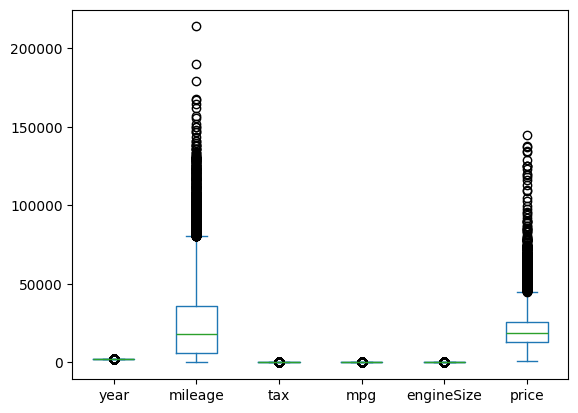

In [10]:
#Gráfico box para variables númericos
df.plot(kind='box')

In [11]:
# Cargar librería para Profiling
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00


In [12]:
# Perfilado de datos
from ydata_profiling import ProfileReport

profile_data=ProfileReport(df, minimal=True) # minimal=False
profile_data

/tmp/ipykernel_1522/1704262744.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 38.34it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [13]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Transformaciones : normalizar y crear dummies

In [14]:
#Transformaciones: normalizar y crear dummies

#Copia de los datos
data=df.copy()



In [15]:
#No se hace balanceo porque no hay variable objetivo

In [16]:
#Normalizacion de variables numéricas
from sklearn.preprocessing import MinMaxScaler


variables_a_normalizar=['year', 'mileage',  'tax',  'mpg', 'engineSize', 'price'] #variables numéricas

min_max_scaler = MinMaxScaler()

min_max_scaler.fit(data[variables_a_normalizar]) #Ajuste de parámetro
data[variables_a_normalizar]= min_max_scaler.transform(data[variables_a_normalizar])
data.head()

,year,transmission,mileage,fuelType,tax,mpg,engineSize,brand,price
0,0.727273,Automatic,0.161393,Hybrid,0.0,1.0,0.0,BMW,0.092455
1,0.727273,Automatic,0.173646,Hybrid,0.0,1.0,0.0,BMW,0.090278
2,0.727273,Automatic,0.198496,Hybrid,0.0,1.0,0.0,BMW,0.099096
3,0.772727,Automatic,0.046192,Hybrid,0.0,1.0,0.0,BMW,0.113220
4,0.772727,Automatic,0.158552,Hybrid,0.0,1.0,0.0,BMW,0.099430


In [17]:
# Si tienen mas de 2 categorías
data = pd.get_dummies(data, columns=['transmission','fuelType','brand'], drop_first=False,  dtype=int) #No borra dummy
data.head()

,year,mileage,tax,mpg,engineSize,price,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Hybrid,fuelType_Petrol,brand_Audi,brand_BMW,brand_Hyundai
0,0.727273,0.161393,0.0,1.0,0.0,0.092455,1,0,0,0,1,0,0,1,0
1,0.727273,0.173646,0.0,1.0,0.0,0.090278,1,0,0,0,1,0,0,1,0
2,0.727273,0.198496,0.0,1.0,0.0,0.099096,1,0,0,0,1,0,0,1,0
3,0.772727,0.046192,0.0,1.0,0.0,0.113220,1,0,0,0,1,0,0,1,0
4,0.772727,0.158552,0.0,1.0,0.0,0.099430,1,0,0,0,1,0,0,1,0


# 2. Aprendizaje del Modelo
* Metodo del codo
* Aplicar kmeans

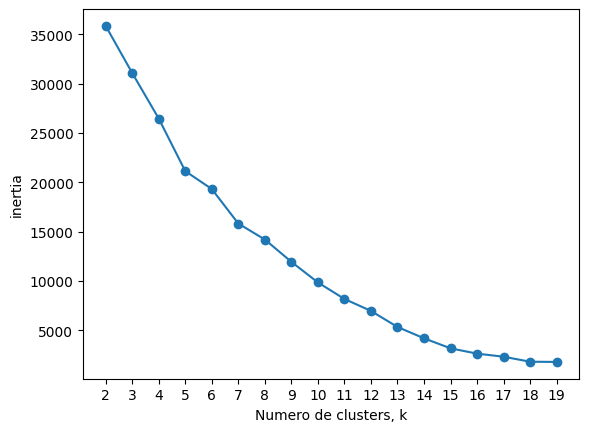

In [18]:
#Método del codo para encontrar la mejor cantidad de clusters: inertia
from sklearn.cluster import KMeans

ks = range(2, 20) # crear valores del 2 al 20
inertias = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=300)
    model.fit(data)
    inertias.append(model.inertia_)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

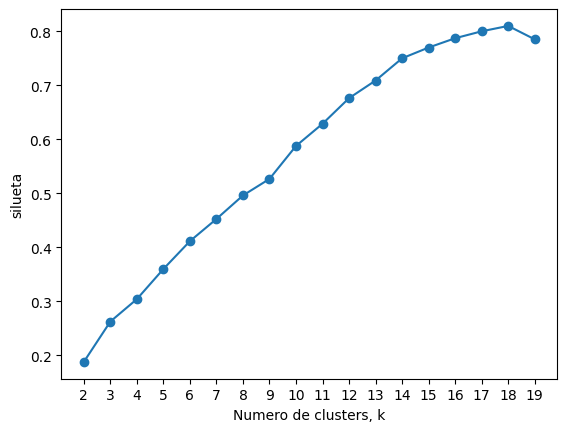

In [19]:
#Método de la rodilla: silueta
from sklearn import metrics

ks = range(2, 20) # crear valores del 2 al 20
siluetas = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=300)
    model.fit(data)
    sil=metrics.silhouette_score(data, model.labels_)
    siluetas.append(sil)

# Graficar cantidad de clusters vs silueta
plt.plot(ks, siluetas, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('silueta')
plt.xticks(ks)
plt.show()

# 3. Evaluación del Modelo


*   Inertia: valor pequeño esperado
*   Silueta: valor positivo esperado, idealmente mayor a 0.5



In [20]:
#Creación de modelo de clustering con Kmeans
from sklearn.cluster import KMeans
k=11
model = KMeans(n_clusters=k, max_iter=300)
model.fit(data) #100% datos

KMeans(n_clusters=11)

In [21]:
#Evaluación
from sklearn import metrics

#Inertia: se require valor pequeño
print('Inercia o cohesión:', model.inertia_)

#Silueta: se requiere que sea positivo, ideal 0.5-1.0
sil=metrics.silhouette_score(data, model.labels_)
print('Silueta:',sil)

Inercia o cohesión: 8073.844824619186
Silueta: 0.630748461421107


In [22]:
#Centroides de los cluster se convierten  en un dataframe de pandas ( tema de entendimiento)
centroides=pd.DataFrame(model.cluster_centers_, columns=data.columns.values)
centroides.round(1)

,year,mileage,tax,mpg,engineSize,price,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Hybrid,fuelType_Petrol,brand_Audi,brand_BMW,brand_Hyundai
0,0.9,0.1,0.3,0.1,0.2,0.2,0.4,-0.0,0.6,0.0,-0.0,1.0,1.0,0.0,0.0
1,0.9,0.1,0.2,0.1,0.3,0.2,-0.0,-0.0,1.0,1.0,0.0,-0.0,-0.0,1.0,0.0
2,0.8,0.2,0.1,0.1,0.2,0.1,-0.0,1.0,-0.0,1.0,0.0,-0.0,1.0,0.0,0.0
3,0.9,0.1,0.2,0.1,0.1,0.1,0.1,0.8,0.1,0.0,0.1,0.9,-0.0,0.0,1.0
4,0.8,0.2,0.2,0.1,0.3,0.1,1.0,0.0,-0.0,0.9,0.1,-0.0,-0.0,1.0,0.0
5,0.9,0.1,0.2,0.1,0.3,0.2,-0.0,0.0,1.0,1.0,0.0,-0.0,0.8,0.0,0.2
6,0.9,0.1,0.2,0.1,0.1,0.1,-0.0,1.0,-0.0,0.0,0.0,1.0,1.0,0.0,0.0
7,0.9,0.1,0.2,0.1,0.3,0.2,1.0,0.0,-0.0,1.0,0.0,-0.0,1.0,0.0,-0.0
8,0.8,0.2,0.2,0.1,0.2,0.1,-0.0,1.0,-0.0,0.6,0.0,0.4,-0.0,1.0,0.0
9,0.8,0.2,0.2,0.1,0.2,0.1,0.2,0.8,-0.0,1.0,0.0,0.0,-0.0,0.0,1.0


In [23]:
# Se realiza una des-normalización centroides
centroides[variables_a_normalizar]=min_max_scaler.inverse_transform(centroides[variables_a_normalizar])
centroides.round(0)

,year,mileage,tax,mpg,engineSize,price,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Hybrid,fuelType_Petrol,brand_Audi,brand_BMW,brand_Hyundai
0,2018.0,15800.0,151.0,42.0,2.0,26978.0,0.0,-0.0,1.0,0.0,-0.0,1.0,1.0,0.0,0.0
1,2018.0,18069.0,135.0,57.0,2.0,26881.0,-0.0,-0.0,1.0,1.0,0.0,-0.0,-0.0,1.0,0.0
2,2016.0,39649.0,81.0,62.0,2.0,15302.0,-0.0,1.0,-0.0,1.0,0.0,-0.0,1.0,0.0,0.0
3,2017.0,17176.0,124.0,53.0,1.0,11839.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.0,0.0,1.0
4,2016.0,35877.0,124.0,67.0,2.0,21512.0,1.0,0.0,-0.0,1.0,0.0,-0.0,-0.0,1.0,0.0
5,2017.0,23635.0,143.0,51.0,2.0,26784.0,-0.0,0.0,1.0,1.0,0.0,-0.0,1.0,0.0,0.0
6,2017.0,22693.0,112.0,52.0,1.0,16859.0,-0.0,1.0,-0.0,0.0,0.0,1.0,1.0,0.0,0.0
7,2017.0,24634.0,144.0,50.0,2.0,28362.0,1.0,0.0,-0.0,1.0,0.0,-0.0,1.0,0.0,-0.0
8,2016.0,34720.0,107.0,59.0,2.0,14637.0,-0.0,1.0,-0.0,1.0,0.0,0.0,-0.0,1.0,0.0
9,2016.0,32590.0,106.0,57.0,2.0,13113.0,0.0,1.0,-0.0,1.0,0.0,0.0,-0.0,0.0,1.0


In [25]:
pd.Series(model.labels_).value_counts()

,count
3,3250
1,3009
0,2813
4,2694
10,2551
8,2527
6,2250
5,2129
2,2118
7,1678


# 4. Perfilamiento

En general, el inventario está compuesto por vehículos usados relativamente recientes, de 2016 a 2018 en promedio, con kilometrajes entre 14.000 y 40.000 millas y precios entre £11.800 y £28.400. Por su interpretación, los 11 clústeres se agrupan en cuatro segmentos. Casi la mitad del inventario (46,3%) pertenece al segmento premium alto automático, seguido del premium de entrada manual (26,2%), el generalista (17,2%) y el premium automático accesible (10,2%).
Premium alto automático (clústeres 0, 1, 5, 7 y 10). Reúne vehículos Audi y BMW recientes, con transmisión automática o semiautomática, menos de 25.000 millas y precios entre £26.800 y £28.400. Internamente se divide en dos grupos. Los de gasolina (clústeres 0 y 10) son los más nuevos, pero también los de menor rendimiento (42 mpg) y mayor impuesto (£151–160). Los diésel (clústeres 1, 5 y 7) tienen mejor rendimiento (50–57 mpg); entre ellos está el clúster 7, un Audi diésel automático que es el más caro del inventario. El clúster 5 es el único que mezcla marcas: 85% Audi y 15% Hyundai.
Premium automático accesible (clúster 4). Formado por BMW automáticos de 2016, mayoritariamente diésel y con un 8% de híbridos. Tiene más kilometraje que el segmento alto (unas 36.000 millas) y el mayor rendimiento del inventario (67 mpg). Ocupa una posición intermedia de precio (£21.500) entre los premium recientes y los premium manuales.
Premium de entrada manual (clústeres 2, 6 y 8). Agrupa Audi y BMW con transmisión manual y precios por debajo de £17.000. El clúster 6 corresponde a Audi de gasolina con motor pequeño y bajo kilometraje. Los clústeres 2 y 8 son mayoritariamente diésel (el 8 incluye un 35% de gasolina), con más kilometraje (35.000–40.000 millas), bajo impuesto y alto rendimiento; el clúster 2 tiene el impuesto más bajo del inventario (£81).
Generalista (clústeres 3 y 9). Corresponde a la marca Hyundai, con los precios más bajos del inventario (£11.800–13.100). El clúster 3 reúne vehículos urbanos de gasolina con motor pequeño y poco kilometraje, e incluye un 11% de híbridos; con 3.250 vehículos es el clúster más grande. El clúster 9 agrupa diésel con mayor kilometraje, de los cuales un 17% son automáticos; con 1.287 vehículos es el más pequeño.
Centroide frente a vehículo típico. Los centroides son promedios y, como el precio y el kilometraje tienen asimetría positiva (numeral 3.3), sobrestiman al vehículo típico. En el segmento premium alto automático, por ejemplo, la mediana corresponde a un vehículo de 2019 con 10.620 millas y un precio de £24.850, frente a los promedios de 2017–2018, 14.000–25.000 millas y £26.800–28.400 del centroide. Para fijar ofertas de compra conviene usar la mediana de cada clúster.
Hallazgos principales
●  Concentración del inventario: el segmento premium alto automático reúne el 46,3% de los vehículos (12.180), por lo que es el que más capital inmoviliza y el que más pesa en la estrategia de compras.
●  Predominio premium: 9 de los 11 clústeres corresponden mayoritariamente a Audi o BMW, en coherencia con la composición del dataset (81,6% de los registros son de estas dos marcas).
●  Predominio diésel: 7 de los 11 clústeres son mayoritariamente diésel, lo que coincide con que este combustible representa el 54% de los registros.
●  Transmisión y precio: todos los clústeres mayoritariamente automáticos o semiautomáticos superan las £21.000, y todos los mayoritariamente manuales están por debajo de £17.000. Esto confirma la asociación entre transmisión y nivel de precio observada en el numeral 3.3.
●  Año y kilometraje: los vehículos más caros son de 2017–2018 con menos de 25.000 millas; los premium más económicos son de 2016 con más de 35.000 millas.
●  Eficiencia frente a precio: los vehículos de gasolina automáticos más recientes tienen el menor rendimiento y el mayor impuesto, mientras que los diésel manuales más antiguos son los más eficientes y los de menor impuesto.
●  Híbridos: no forman un segmento propio. Su presencia es marginal (2,6% del dataset) y aparece repartida principalmente en los clústeres 3 (11%) y 4 (8%).
Implicaciones para la estrategia de compras y rotación
De acuerdo con el objetivo del M3 (numeral 1.3), los segmentos orientan la captación y la venta de vehículos de la siguiente manera:
Segmento
Compras (captación)
Rotación y venta
Premium alto automático
Captar vehículos de 2017–2018 con menos de 25.000 millas: en este segmento el precio se sostiene por la antigüedad y el bajo kilometraje, así que la oferta de compra debe ser muy sensible a cada año adicional y a cada tramo de millas. Diferenciar la oferta entre gasolina y diésel, porque el mayor impuesto y menor rendimiento de los de gasolina son argumentos de negociación del comprador final.
Es el segmento de mayor ticket y mayor capital inmovilizado. Venta con certificación, garantía extendida y financiación con cuota final; para los diésel, canal empresarial (renting y flotas).
Premium automático accesible
BMW automáticos de 2016 con kilometraje medio. Su alto rendimiento (67 mpg) a un precio intermedio los hace atractivos para la reventa; los híbridos de este grupo merecen una valoración específica.
Funciona como puente entre segmentos: atrae a clientes del segmento de entrada que quieren pasar a un automático. Mensaje centrado en eficiencia y garantía mecánica para mitigar el kilometraje.
Premium de entrada manual
Por su kilometraje alto (35.000–40.000 millas en los clústeres 2 y 8), exigir historial de servicio e inspección y ofertar descontando el costo de reacondicionamiento.
Venta con financiación de cuota baja y en marketplaces, posicionada como “primer premium”. El kilometraje es la principal objeción de venta, por lo que la transparencia del historial acelera la rotación.
Generalista
Compra por volumen con margen unitario bajo: ofertar a precio ajustado y minimizar el gasto de reacondicionamiento.
Debe ser el segmento de rotación más rápida: precio competitivo, proceso de venta ágil y enfoque en primer auto, conductores noveles y familias con presupuesto ajustado.



<Axes: ylabel='count'>

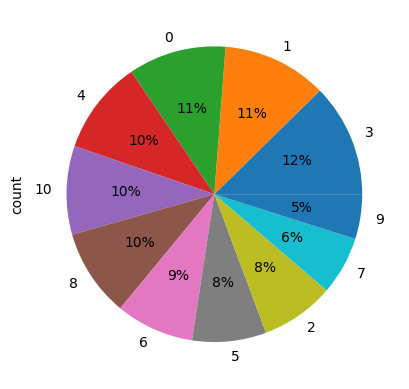

In [26]:
df['cluster'] = model.labels_
df['cluster'].value_counts().plot(kind='pie',autopct='%.0f%%')

In [27]:
#Almacenar resultados
df.to_excel('./resultados_Kmeans.xlsx')
centroides.to_excel('./centroides.xlsx')
